<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-8-Generalized_Solutions/Untitled182.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Generalized Solutions**

We consider the Cauchy problem
$$
u''(x)=H(x),
\qquad
u(0)=0,
\qquad
u'(0)=0,
$$
where $H(x)$ denotes the Heaviside function.

The exact generalized solution is
$$
u_{\mathrm{exact}}(x)
=
\frac{x^2}{2}\,H(x).
$$



We approximate the solution by a neural network
$$
u_\theta(x)=NN(\theta;x),
$$
trained to minimize the loss
\begin{align*}
\mathcal{L}_{\mathrm{total}}(\theta)
=&
\frac{\alpha_0}{N}
\sum_{i=1}^N
\left|
\int_{-1}^{1}
u_\theta(x)\,\varphi_i''(x)\,dx
-
\int_{-1}^{1}
H(x)\,\varphi_i(x)\,dx
\right|^2 \\
&
+
\alpha |u_\theta(0)|^2
+
\beta |u_\theta'(0)|^2.
\end{align*}


Epoch     0 | Total = 1.248842e+01 | Weak = 1.560e-01 | u(0) = 0.000e+00 | u'(0) = 9.368e-02
Epoch   500 | Total = 1.253399e-01 | Weak = 6.266e-03 | u(0) = 1.532e-07 | u'(0) = 7.432e-08
Epoch  1000 | Total = 1.138042e-01 | Weak = 5.690e-03 | u(0) = 7.022e-09 | u'(0) = 5.684e-14
Epoch  1500 | Total = 1.014985e-01 | Weak = 5.075e-03 | u(0) = 1.498e-09 | u'(0) = 4.025e-09
Epoch  2000 | Total = 7.586752e-02 | Weak = 3.793e-03 | u(0) = 1.045e-09 | u'(0) = 8.891e-10
Epoch  2500 | Total = 4.979474e-02 | Weak = 2.490e-03 | u(0) = 6.511e-11 | u'(0) = 3.308e-09
Epoch  3000 | Total = 2.455457e-02 | Weak = 1.228e-03 | u(0) = 3.354e-08 | u'(0) = 3.022e-09
Epoch  3500 | Total = 2.464081e-02 | Weak = 1.232e-03 | u(0) = 1.201e-09 | u'(0) = 1.003e-09
Epoch  4000 | Total = 1.212280e-02 | Weak = 6.020e-04 | u(0) = 2.102e-07 | u'(0) = 6.183e-07
Epoch  4500 | Total = 9.628624e-03 | Weak = 4.814e-04 | u(0) = 6.487e-11 | u'(0) = 1.106e-09
Epoch  5000 | Total = 5.660850e-03 | Weak = 2.791e-04 | u(0) = 4.426e-

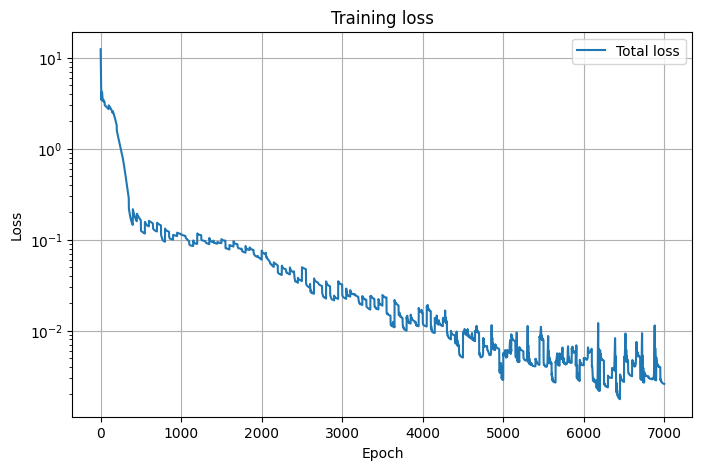

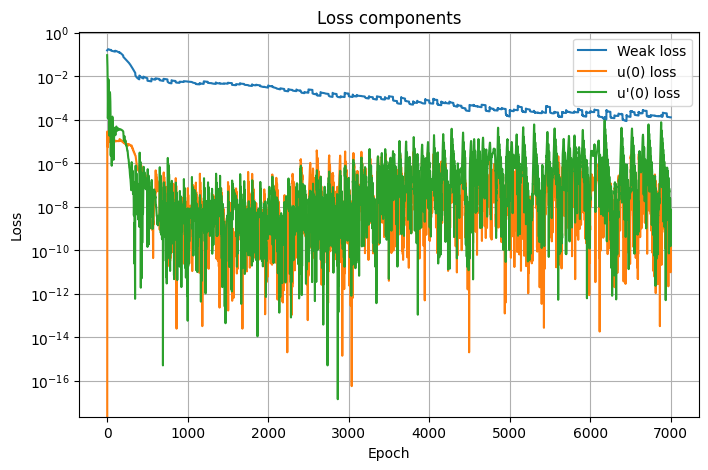

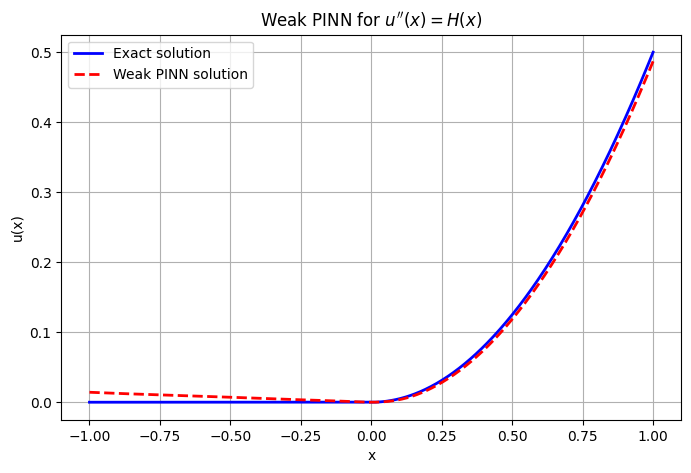

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# Problem: u''(x)=H(x), u(0)=0, u'(0)=0
# Exact solution: u(x)=0.5*x^2*H(x)
# =========================

# Domain
a, b = -1.0, 1.0
L = b - a

# Training parameters
N_quad = 5000
N_tests = 160
EPOCHS = 7000
RESAMPLE_EVERY = 50

alpha_weak = 20.0
alpha_u0 = 100.0
alpha_du0 = 100.0

r_min = 0.05
r_max = 0.30

# =========================
# Exact solution
# =========================
def H_np(x):
    return np.where(x >= 0, 1.0, 0.0)

def exact_solution(x):
    return 0.5 * x**2 * H_np(x)

# =========================
# Neural network
# =========================
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])

model = build_model()
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)

# =========================
# Quadrature points
# =========================
x_quad_np = np.linspace(a, b, N_quad).reshape(-1, 1)
x_quad = tf.constant(x_quad_np, dtype=tf.float32)

H_quad = tf.constant(H_np(x_quad_np), dtype=tf.float32)

# Initial point
x0 = tf.constant([[0.0]], dtype=tf.float32)

# =========================
# Bump functions
# =========================
def sample_log_uniform(rmin, rmax, size):
    return np.exp(np.random.uniform(np.log(rmin), np.log(rmax), size))

def sample_bump_parameters():
    radii_np = sample_log_uniform(r_min, r_max, (N_tests, 1))

    centers_np = []
    for r in radii_np.flatten():
        c = np.random.uniform(a + r, b - r)
        centers_np.append([c])

    centers = tf.constant(np.array(centers_np), dtype=tf.float32)
    radii = tf.constant(radii_np, dtype=tf.float32)

    return centers, radii

def bump_values(x, center, r):
    z = (x - center) / r
    rho2 = tf.square(z)

    mask = rho2 < 1.0
    rho2_safe = tf.clip_by_value(rho2, 0.0, 1.0 - 1e-6)

    val_inside = tf.exp(1.0 / (rho2_safe - 1.0))
    val = tf.where(mask, val_inside, tf.zeros_like(val_inside))

    return val / r

def compute_bumps_and_second_derivatives(x_quad, centers, radii):
    phi_list = []
    phi_xx_list = []

    for j in range(N_tests):
        c = centers[j:j+1, :]
        r = radii[j:j+1, :]

        with tf.GradientTape() as tape2:
            tape2.watch(x_quad)

            with tf.GradientTape() as tape1:
                tape1.watch(x_quad)
                phi = bump_values(x_quad, c, r)

            phi_x = tape1.gradient(phi, x_quad)

        phi_xx = tape2.gradient(phi_x, x_quad)

        phi_list.append(phi)
        phi_xx_list.append(phi_xx)

    phi_quad = tf.concat(phi_list, axis=1)
    phi_xx_quad = tf.concat(phi_xx_list, axis=1)

    return phi_quad, phi_xx_quad

# =========================
# Initial test functions
# =========================
centers, radii = sample_bump_parameters()
phi_quad, phi_xx_quad = compute_bumps_and_second_derivatives(
    x_quad, centers, radii
)

# IMPORTANT:
# Normalize by the size of phi, not by the size of phi_xx.
# Dividing by ||phi_xx|| makes the forcing term too small.
phi_norm = tf.sqrt(tf.reduce_mean(tf.square(phi_quad), axis=0) + 1e-8)

# =========================
# Loss function
# Weak form:
# ∫ u phi'' dx = ∫ H phi dx
# =========================
def compute_loss(phi_quad, phi_xx_quad, phi_norm):
    u_quad = model(x_quad)

    left_integrals = L * tf.reduce_mean(u_quad * phi_xx_quad, axis=0)
    right_integrals = L * tf.reduce_mean(H_quad * phi_quad, axis=0)

    residuals = (left_integrals - right_integrals) / phi_norm
    loss_weak = tf.reduce_mean(tf.square(residuals))

    # u(0)=0
    u0 = model(x0)
    loss_u0 = tf.reduce_mean(tf.square(u0))

    # u'(0)=0
    with tf.GradientTape() as tape:
        tape.watch(x0)
        u0_for_derivative = model(x0)

    du0 = tape.gradient(u0_for_derivative, x0)
    loss_du0 = tf.reduce_mean(tf.square(du0))

    total_loss = (
        alpha_weak * loss_weak
        + alpha_u0 * loss_u0
        + alpha_du0 * loss_du0
    )

    return total_loss, loss_weak, loss_u0, loss_du0

# =========================
# Training loop
# =========================
loss_history = []
weak_history = []
u0_history = []
du0_history = []

for epoch in range(EPOCHS):

    if epoch % RESAMPLE_EVERY == 0:
        centers, radii = sample_bump_parameters()
        phi_quad, phi_xx_quad = compute_bumps_and_second_derivatives(
            x_quad, centers, radii
        )
        phi_norm = tf.sqrt(tf.reduce_mean(tf.square(phi_quad), axis=0) + 1e-8)

    with tf.GradientTape() as tape:
        loss, loss_weak, loss_u0, loss_du0 = compute_loss(
            phi_quad, phi_xx_quad, phi_norm
        )

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy().item())
    weak_history.append(loss_weak.numpy().item())
    u0_history.append(loss_u0.numpy().item())
    du0_history.append(loss_du0.numpy().item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total = {loss_history[-1]:.6e} | "
            f"Weak = {weak_history[-1]:.3e} | "
            f"u(0) = {u0_history[-1]:.3e} | "
            f"u'(0) = {du0_history[-1]:.3e}"
        )

# =========================
# Plot loss
# =========================
plt.figure(figsize=(8,5))
plt.plot(loss_history, label="Total loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid()
plt.legend()
plt.show()

# =========================
# Plot loss components
# =========================
plt.figure(figsize=(8,5))
plt.plot(weak_history, label="Weak loss")
plt.plot(u0_history, label="u(0) loss")
plt.plot(du0_history, label="u'(0) loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss components")
plt.grid()
plt.legend()
plt.show()

# =========================
# Plot exact vs neural solution
# =========================
x_plot = np.linspace(a, b, 800).reshape(-1, 1)
x_plot_tf = tf.constant(x_plot, dtype=tf.float32)

u_nn = model(x_plot_tf).numpy().flatten()
u_ex = exact_solution(x_plot.flatten())

plt.figure(figsize=(8,5))
plt.plot(x_plot, u_ex, "b-", linewidth=2, label="Exact solution")
plt.plot(x_plot, u_nn, "r--", linewidth=2, label="Weak PINN solution")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(r"Weak PINN for $u''(x)=H(x)$")
plt.legend()
plt.grid()
plt.show()